In [1]:
%load_ext autoreload
%autoreload 2

Analyze fit TRFs -- hparams and coefficients.

In [281]:
from pathlib import Path
import pickle
import re

from fastdist import fastdist
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import get_electrode_df

In [3]:
trf_paths = list(Path("outputs/trfs").glob("**/results.pkl"))
outdir = "."

In [4]:
all_trf_paths = [Path(p) for p in trf_paths]

In [5]:
all_trfs = {}
for trf_path in all_trf_paths:
    with open(trf_path, "rb") as f:
        trf = pickle.load(f)
    all_trfs[trf_path.parent.name] = trf

In [298]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in all_trfs.keys()],
                         keys=all_trfs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")
electrode_df.index.names = ["subject", "electrode"]

# Drop electrodes metadata which don't have corresponding data
for subject, trf_i in all_trfs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < trf_i["unique_variance_df"].columns.stop
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode                                                  
EC287   0          TemporalGrid1   grid              middletemporal
        1          TemporalGrid2   grid              middletemporal
        2          TemporalGrid3   grid              middletemporal
        3          TemporalGrid4   grid              middletemporal
        4          TemporalGrid5   grid              middletemporal
...                          ...    ...                         ...
EC282   217         Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218         Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219         Hippocampus8  depth  Left-Cerebral-White-Matter
        220         Hippocampus9  depth       ctx_lh_G_temporal_inf
        221        Hippocampus10  depth  Left-Cerebral-White-Matter

[2460 rows x 3 columns]

In [6]:
all_unique_variance = pd.concat([
    trf_data["unique_variance_df"].groupby("feature_block").mean()
        .reset_index().melt(id_vars="feature_block", value_name="unique_variance")
    for _, trf_data in all_trfs.items()
], keys=list(all_trfs.keys()), names=["subject"]).droplevel(-1).sort_values("unique_variance", ascending=False).dropna()
all_unique_variance.head(20)

,feature_block,electrode,unique_variance
subject,,,
EC250,acoustic,215,0.017799
EC282,acoustic,84,0.011961
EC248,acoustic,382,0.011833
EC243,mismatch,102,0.011563
EC260,mismatch,204,0.011078
EC278,lexical_evidence,85,0.010802
EC253,acoustic,21,0.009562
EC279,lexical_evidence,7,0.007250
EC279,lexical_evidence,166,0.005628


In [7]:
all_unique_variance.groupby("subject").head(5)

,feature_block,electrode,unique_variance
subject,,,
EC250,acoustic,215,0.017799
EC282,acoustic,84,0.011961
EC248,acoustic,382,0.011833
EC243,mismatch,102,0.011563
EC260,mismatch,204,0.011078
EC278,lexical_evidence,85,0.010802
EC253,acoustic,21,0.009562
EC279,lexical_evidence,7,0.007250
EC279,lexical_evidence,166,0.005628


In [8]:
uv_df = all_unique_variance[all_unique_variance.feature_block.isin(("acoustic", "mismatch", "lexical_evidence"))] \
    .set_index(["electrode", "feature_block"], append=True).unique_variance.unstack().fillna(0)
uv_df[uv_df < 0] = 0
joint_uv_df = uv_df[(uv_df > 0).sum(axis=1) >= 2]
joint_uv_df["mean"] = joint_uv_df.mean(axis=1)
joint_uv_df.sort_values("mean", ascending=False).head(20)

/tmp/ipykernel_2982143/1441369838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joint_uv_df["mean"] = joint_uv_df.mean(axis=1)


feature_block      acoustic  lexical_evidence  mismatch      mean
subject electrode                                                
EC250   215        0.017799          0.000204  0.001450  0.006484
EC243   102        0.003124          0.001660  0.011563  0.005449
EC248   382        0.011833          0.002259  0.000000  0.004697
EC260   204        0.000000          0.000561  0.011078  0.003880
        91         0.000000          0.005251  0.005591  0.003614
EC253   21         0.009562          0.001263  0.000000  0.003608
EC243   197        0.000000          0.004800  0.005430  0.003410
EC250   216        0.005210          0.001425  0.002870  0.003168
EC248   381        0.005302          0.000000  0.002286  0.002529
EC260   219        0.000000          0.002065  0.004416  0.002160
        109        0.000000          0.000961  0.005288  0.002083
EC279   166        0.000000          0.005628  0.000398  0.002009
EC260   222        0.001368          0.000894  0.003570  0.001944
EC248   365        0.005014          0.000000  0.000739  0.001918
EC260   93         0.000000          0.000057  0.005562  0.001873
EC253   180        0.004677          0.000900  0.000000  0.001859
EC279   6          0.000000          0.004638  0.000890  0.001843
EC282   116        0.000000          0.004038  0.001086  0.001708
EC253   179        0.002809          0.002239  0.000000  0.001683
EC270   139        0.000939          0.002571  0.001502  0.001671

## Model performance

In [9]:
perf_df = pd.merge(pd.DataFrame.from_dict({s: v["test_score"] for s, v in all_trfs.items()}, orient="index").reset_index().melt(id_vars=["index"], value_name="test_score"),
         pd.DataFrame.from_dict({s: v["train_score"] for s, v in all_trfs.items()}, orient="index").reset_index().melt(id_vars=["index"], value_name="train_score"),
         on=["index", "variable"])
perf_df

,index,variable,test_score,train_score
0,EC287,0,0.001274,0.013522
1,EC270,0,0.000860,0.016942
2,EC248,0,0.008936,0.012066
3,EC260,0,0.007031,0.013890
4,EC279,0,0.009039,0.013263
5,EC243,0,0.008788,0.012918
6,EC250,0,0.011064,0.012337
7,EC278,0,0.007720,0.010333
8,EC253,0,0.009065,0.013559
9,EC282,0,0.004403,0.024529


<Axes: xlabel='index', ylabel='score'>

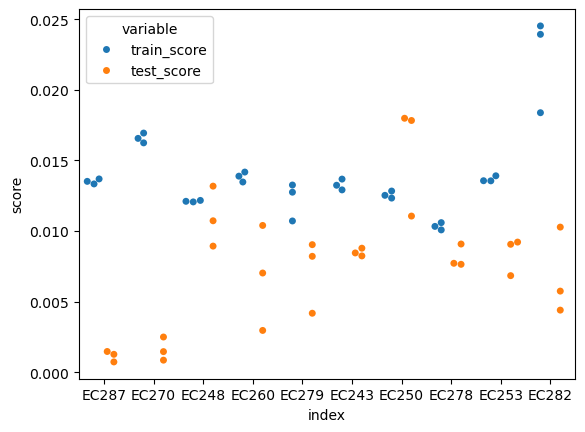

In [10]:
sns.swarmplot(data=perf_df.melt(id_vars=["index"], value_vars=["train_score", "test_score"], value_name="score"),
              x="index", hue="variable", y="score", dodge=True)

## Hparam analysis

In [11]:
all_alphas = []
for trf_name, trf in all_trfs.items():
    for fit in trf["estimators"]:
        assert isinstance(fit.estimator, float)
        all_alphas.append((trf_name, fit.estimator))

In [12]:
Cs = np.logspace(-4, 2, 7)
Cs

array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

In [13]:
trf_hparams = pd.DataFrame(all_alphas, columns=["trf", "alpha"])
trf_hparams["log_alpha"] = np.log10(trf_hparams["alpha"])
trf_hparams

,trf,alpha,log_alpha
0,EC287,100.0,2.0
1,EC287,100.0,2.0
2,EC287,100.0,2.0
3,EC270,100.0,2.0
4,EC270,100.0,2.0
5,EC270,100.0,2.0
6,EC248,0.1,-1.0
7,EC248,0.1,-1.0
8,EC248,1.0,0.0
9,EC260,0.1,-1.0


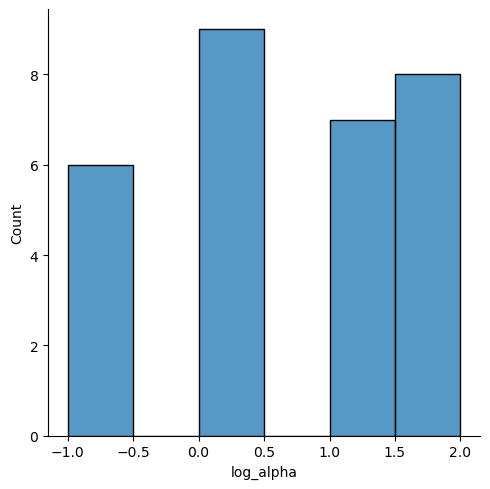

In [14]:
sns.displot(data=trf_hparams, x="log_alpha")

In [15]:
trf_hparams["alpha_at_lower_bound"] = trf_hparams["alpha"] == Cs[0]
trf_hparams["alpha_at_upper_bound"] = trf_hparams["alpha"] == Cs[-1]
trf_hparams

,trf,alpha,log_alpha,alpha_at_lower_bound,alpha_at_upper_bound
0,EC287,100.0,2.0,False,True
1,EC287,100.0,2.0,False,True
2,EC287,100.0,2.0,False,True
3,EC270,100.0,2.0,False,True
4,EC270,100.0,2.0,False,True
5,EC270,100.0,2.0,False,True
6,EC248,0.1,-1.0,False,False
7,EC248,0.1,-1.0,False,False
8,EC248,1.0,0.0,False,False
9,EC260,0.1,-1.0,False,False


## Extract coefficients

In [16]:
dir(next(iter(all_trfs.values()))["estimators"][0])

all_coefficients = {}
feature_names = None
for subject, trf in all_trfs.items():
    subject_coefs = []
    for fit in trf["estimators"]:
        if feature_names is None:
            feature_names = fit.feature_names
        else:
            assert feature_names == fit.feature_names
        subject_coefs.append(fit.coef_)
    all_coefficients[subject] = np.array(subject_coefs)

In [17]:
next(iter(all_trfs.values()))["estimators"][0].delays_

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,
        16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70])

In [18]:
def get_coef_means(subject, channel):
    # return pd.DataFrame(all_coefficients[subject][:, channel, :].mean(axis=0), index=pd.Index(feature_names, name="feature")) \
    #     .reset_index().melt(id_vars=["feature"], var_name="delay")
    ret = {feature: all_coefficients[subject][:, channel, idx, :].mean(axis=0)
           for idx, feature in enumerate(feature_names)}
    return ret

### Cross-cue similarity

In [20]:
from dtaidistance import dtw
def get_cross_cue_similarity(subject, channel, cues=("categorical_acoustic_cue", "lexical_evidence_cue")):
    coefs = get_coef_means(subject, channel)

    # normalize
    all_coefs = np.array(list(coefs.values()))
    all_coef_max = all_coefs.max()
    all_coef_min = all_coefs.min()
    coefs = {feature: (coef - all_coef_min) / (all_coef_max - all_coef_min) for feature, coef in coefs.items()}

    coefs = {tuple(feature.split("-")): coef for feature, coef in coefs.items()}
    all_phoneme_pairs = set(feature_tuple[1] for feature_tuple in coefs.keys())

    ret = []
    for phoneme_pair in all_phoneme_pairs:
        dist = dtw.distance_fast(*[coefs[(cue, phoneme_pair)] for cue in cues])
        ret.append((phoneme_pair, dist))

    return ret

cross_cue_results = {(subject, channel): get_cross_cue_similarity(subject, channel)
                     for subject, trf in all_trfs.items()
                     for channel in range(trf["estimators"][0].coef_.shape[0])}

In [21]:
cross_cue_df = pd.concat({k: pd.DataFrame.from_records(v, columns=["phoneme_pair", "distance"]) for k, v in cross_cue_results.items()},
                         names=["subject", "channel"]).droplevel(-1).sort_values("distance").reset_index()
cross_cue_df = pd.merge(cross_cue_df.groupby(["subject", "channel"]).distance.min().reset_index(),
                        uv_df[uv_df.sum(axis=1) > 0],
                        how="inner",
                        left_on=["subject", "channel"],
                        right_on=["subject", "electrode"])
cross_cue_df

,subject,channel,distance,acoustic,lexical_evidence,mismatch
0,EC243,71,0.473691,0.001822,0.000000,0.000000
1,EC243,72,0.521591,0.000000,0.000000,0.000116
2,EC243,87,0.525826,0.002814,0.000000,0.000000
3,EC243,88,0.846787,0.001250,0.000000,0.000000
4,EC243,102,0.342203,0.003124,0.001660,0.011563
...,...,...,...,...,...,...
139,EC287,56,0.680133,0.000000,0.000587,0.000000
140,EC287,59,0.528675,0.000000,0.000022,0.000523
141,EC287,124,0.840822,0.000033,0.000114,0.000891
142,EC287,147,0.331628,0.000000,0.002225,0.000000


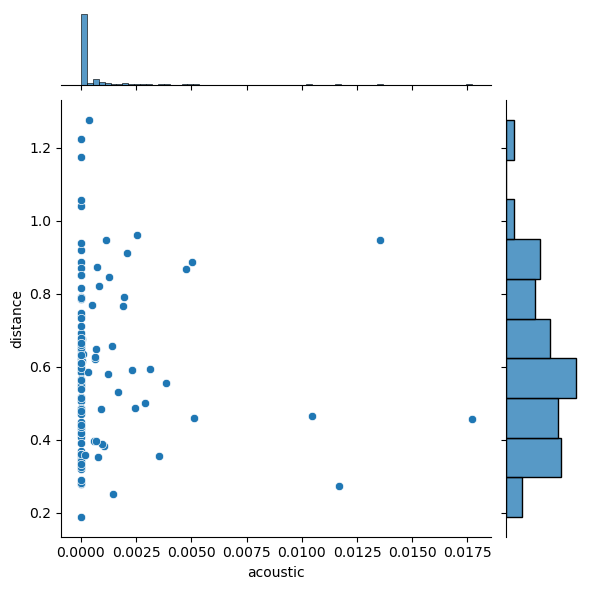

In [172]:
sns.jointplot(data=cross_cue_df, x="acoustic", y="distance")

In [173]:
cross_cue_df[(cross_cue_df.acoustic > 0.0025)].sort_values("distance")

,subject,channel,distance,acoustic,lexical_evidence,mismatch
19,EC248,382,0.274564,0.011675,0.001958,0.000000
4,EC243,102,0.356431,0.003536,0.000838,0.011920
22,EC250,215,0.456145,0.017687,0.000375,0.001671
109,EC282,117,0.459894,0.005108,0.005018,0.000349
26,EC253,21,0.465228,0.010441,0.001603,0.000000
1,EC243,87,0.499849,0.002908,0.000000,0.000082
32,EC253,52,0.555860,0.003830,0.000879,0.000000
18,EC248,381,0.593065,0.003109,0.000000,0.002287
35,EC253,180,0.869314,0.004775,0.001517,0.000000
23,EC250,216,0.887369,0.005014,0.001132,0.002824


### Cluster

In [384]:
cluster_X, cluster_labels = [], []
cluster_include_percentile = 50
for subject, subject_coefs in all_coefficients.items():
    # cluster_targets = uv_df[(uv_df.mismatch > 0) | (uv_df.lexical_evidence > 0)].loc[subject]
    try:
        cluster_targets = uv_df[(uv_df.mismatch > np.percentile(uv_df.mismatch[uv_df.mismatch > 0], cluster_include_percentile))].loc[subject]
    except:
        continue

    for phoneme_pair in ["bm", "dn", "pb"]:
        mismatch_coefs = subject_coefs[:, cluster_targets.index, feature_names.index(f"mismatch_left_right-{phoneme_pair}"), :].mean(0)
        mismatch2_coefs = subject_coefs[:, cluster_targets.index, feature_names.index(f"mismatch-{phoneme_pair}"), :].mean(0)
        # lex_coefs = subject_coefs[:, cluster_targets.index, feature_names.index(f"lexical_evidence_cue-{phoneme_pair}"), :].mean(0)

        # rolling average over second axis
        mismatch_coefs = np.array([mismatch_coefs[:, i:i+3].mean(1) for i in range(mismatch_coefs.shape[1] - 2)]).T
        mismatch_coefs = mismatch_coefs[:, ::3]
        mismatch2_coefs = np.array([mismatch2_coefs[:, i:i+3].mean(1) for i in range(mismatch2_coefs.shape[1] - 2)]).T
        mismatch2_coefs = mismatch2_coefs[:, ::3]
        # lex_coefs = np.array([lex_coefs[:, i:i+3].mean(1) for i in range(lex_coefs.shape[1] - 2)]).T
        # lex_coefs = lex_coefs[:, ::3]

        # cluster_X.append(np.concatenate([mismatch_coefs, mismatch2_coefs, lex_coefs], axis=1))
        cluster_X.append(np.concatenate([mismatch_coefs, mismatch2_coefs], axis=1))
        cluster_labels.extend((subject, phoneme_pair, electrode_idx) for electrode_idx in cluster_targets.index)

cluster_X = np.concatenate(cluster_X)
cluster_X -= cluster_X.mean(axis=0)
cluster_X /= cluster_X.std(axis=0)

assert cluster_X.shape[0] == len(cluster_labels)

In [386]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(cluster_X)
pca = PCA(n_components=2)
cluster_X_pca = pca.fit_transform(cluster_X)

In [387]:
cluster_df = pd.DataFrame(cluster_labels, columns=["subject", "phoneme_pair", "electrode"])
cluster_df["cluster"] = kmeans.labels_

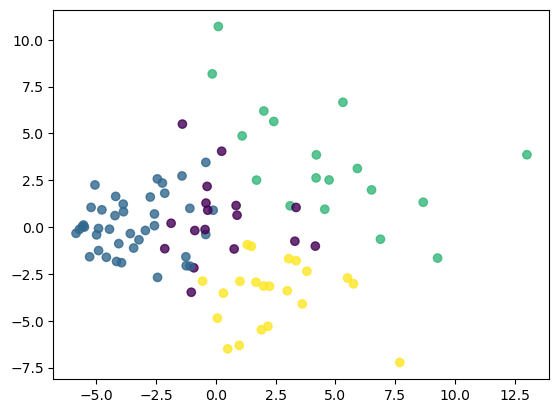

In [388]:
import matplotlib.pyplot as plt

plt.scatter(cluster_X_pca[:, 0], cluster_X_pca[:, 1], c=kmeans.labels_, alpha=0.8)

In [389]:
cluster_df.cluster.value_counts()

cluster
1    40
3    21
2    18
0    17
Name: count, dtype: int64

<Axes: >

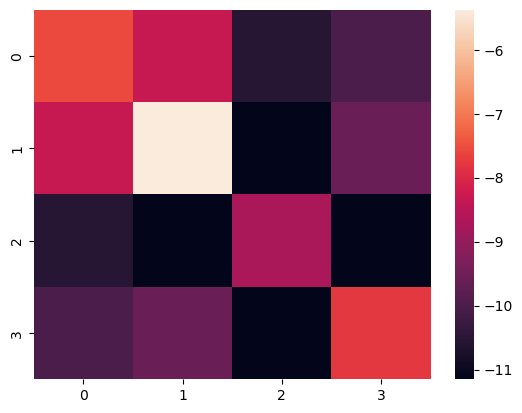

In [390]:
cluster_dists = np.zeros((kmeans.n_clusters, kmeans.n_clusters))
for i in range(kmeans.n_clusters):
    for j in range(kmeans.n_clusters):
        vecs_i = cluster_X[kmeans.labels_ == i]
        vecs_j = cluster_X[kmeans.labels_ == j]
        cluster_dists[i, j] = 1 - fastdist.matrix_to_matrix_distance(vecs_i, vecs_j, fastdist.euclidean, "euclidean").mean()

sns.heatmap(cluster_dists)

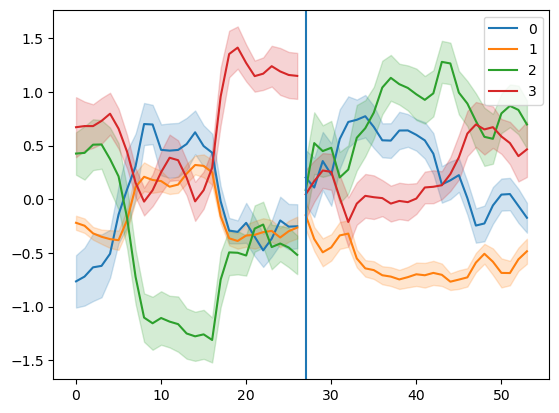

In [391]:
cmap = sns.color_palette("tab10", n_colors=kmeans.n_clusters)
for cluster, rows in cluster_df.groupby("cluster"):
    xs = cluster_X[rows.index]
    split_point = cluster_X.shape[1] // 2

    first_xs, second_xs = xs[:, :split_point], xs[:, split_point:]
    plt.plot(first_xs.mean(0), label=cluster, c=cmap[cluster])
    plt.plot(np.arange(split_point, xs.shape[1]), second_xs.mean(0), c=cmap[cluster])

    plt.fill_between(np.arange(0, split_point), first_xs.mean(0) - first_xs.std(0) / np.sqrt(first_xs.shape[0]), first_xs.mean(0) + first_xs.std(0) / np.sqrt(first_xs.shape[0]),
                     alpha=0.2, color=cmap[cluster])
    plt.fill_between(np.arange(split_point, xs.shape[1]), second_xs.mean(0) - second_xs.std(0) / np.sqrt(second_xs.shape[0]), second_xs.mean(0) + second_xs.std(0) / np.sqrt(second_xs.shape[0]),
                     alpha=0.2, color=cmap[cluster])


plt.axvline(split_point)
plt.legend()

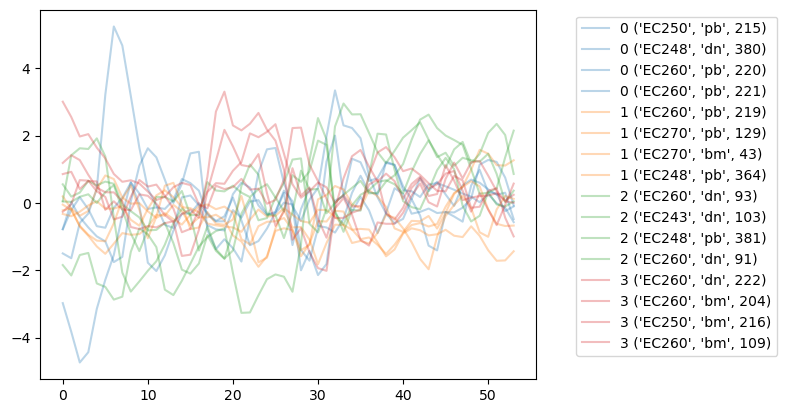

In [392]:
plot_n = 4
plot_idxs = cluster_df.groupby("cluster").sample(plot_n).index

cmap = sns.color_palette("tab10", n_colors=kmeans.n_clusters)
for i in plot_idxs:
    plt.plot(cluster_X[i], label=f"{cluster_df.iloc[i].cluster} {cluster_labels[i]}",
             c=cmap[cluster_df.iloc[i].cluster], alpha=0.3)
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1))

In [393]:
# Find sites closest to each cluster centroid
find_k_neighbors = 4
centroid_neighbors = []
for i, cluster_center in enumerate(kmeans.cluster_centers_):
    dists = fastdist.vector_to_matrix_distance(cluster_center, cluster_X, fastdist.euclidean, "euclidean")
    closest_idxs = np.argsort(dists)[:find_k_neighbors]
    centroid_neighbors.extend((i, dists[idx]) + cluster_labels[idx] for idx in closest_idxs)
centroid_neighbors_df = pd.DataFrame(centroid_neighbors, columns=["cluster", "dist", "subject", "phoneme_pair", "electrode"])

In [394]:
centroid_neighbors_df

,cluster,dist,subject,phoneme_pair,electrode
0,0,3.665784,EC270,dn,122
1,0,4.458564,EC260,pb,204
2,0,4.595923,EC243,pb,103
3,0,5.177221,EC243,dn,119
4,1,2.508093,EC270,pb,131
5,1,2.626039,EC270,bm,131
6,1,2.673041,EC270,bm,133
7,1,2.823132,EC270,pb,139
8,2,4.772718,EC260,dn,109
9,2,5.057221,EC260,dn,93


In [319]:
pd.merge(cluster_df, uv_df, left_on=["subject", "electrode"], right_on=["subject", "electrode"]).groupby("cluster")[["acoustic", "lexical_evidence", "mismatch"]].median()

,acoustic,lexical_evidence,mismatch
cluster,,,
0,0.0,0.000701,0.001667
1,0.0,0.000674,0.000243
2,0.0,0.001626,0.000000
3,0.0,0.000763,0.000000
4,0.0,0.000639,0.002389


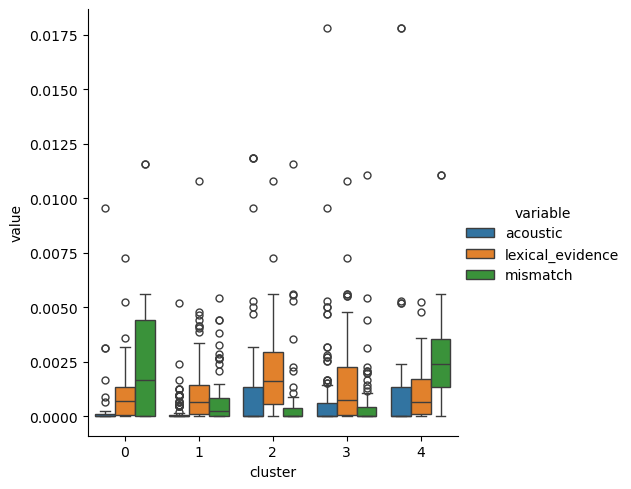

In [323]:
sns.catplot(data=pd.merge(cluster_df, uv_df, left_on=["subject", "electrode"], right_on=["subject", "electrode"]).melt(id_vars=["subject", "electrode", "cluster"], value_vars=["acoustic", "lexical_evidence", "mismatch"]),
            x="cluster", y="value", hue="variable", kind="box")

### Coef plots

In [22]:
def plot_features(feature_pattern, subject, channel, show_all=False):
    plot_features = [feat for feat in feature_names
                    if re.search(feature_pattern, feat)]
    plot_coefs = all_coefficients[subject][:, channel, :, :]
    print(plot_coefs.shape)

    phoneme_pairs = sorted(set([feat.split("-")[1] for feat in plot_features]))
    palette = sns.color_palette("tab10", len(phoneme_pairs))
    cues = sorted(set([feat.split("-")[0] for feat in plot_features]))
    styles = ["-", "--", "-.", ":"]
    assert len(cues) <= len(styles)

    sample_est = next(iter(all_trfs.values()))["estimators"][0]
    times = sample_est.delays_ / sample_est.sfreq

    f, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.axhline(0, color="gray", linestyle="--")
    ax.axvline(0, color="gray", linestyle="--")
    coef_means = []
    for feat in plot_features:
        feat_idx = feature_names.index(feat)
        feat_coefs = plot_coefs[:, feat_idx, :]

        cue, phoneme_pair = feat.split("-")
        color = palette[phoneme_pairs.index(phoneme_pair)]
        style = styles[cues.index(cue)]

        coef_mean = feat_coefs.mean(axis=0)
        coef_means.append(coef_mean)

        ax.plot(times, coef_mean, label=feat, color=color, linestyle=style)
        if show_all:
            for fold_coef in feat_coefs:
                ax.plot(times, fold_coef, color=color, linestyle=style, alpha=0.2)
        else:
            ax.fill_between(times,
                            feat_coefs.mean(axis=0) - feat_coefs.std(axis=0) / np.sqrt(feat_coefs.shape[0]),
                            feat_coefs.mean(axis=0) + feat_coefs.std(axis=0) / np.sqrt(feat_coefs.shape[0]),
                            color=color, alpha=0.2)
        
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))

    return plot_features, np.array(coef_means)

(3, 12, 81)


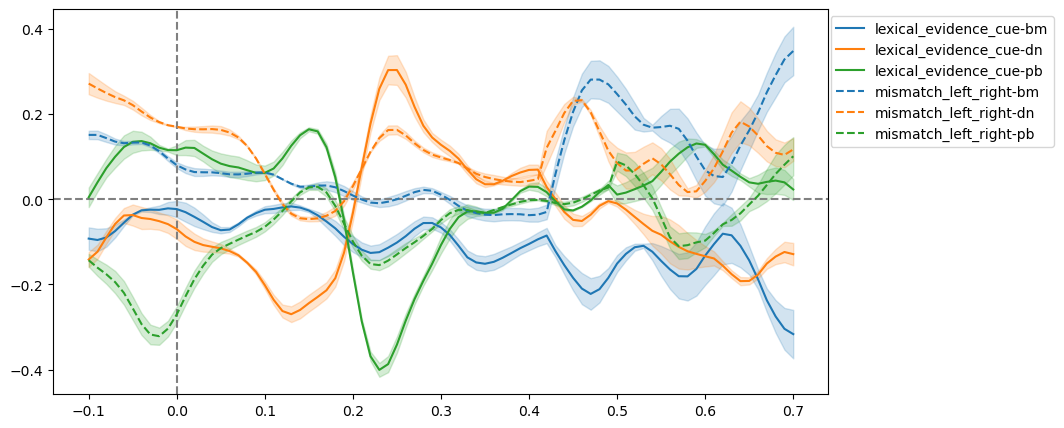

In [23]:
plot_features(r"linear_acoustic|lexical_evidence|mismatch_left_right", "EC250", 215)
None

(4, 18, 81)


(['linear_acoustic_cue-bm',
  'linear_acoustic_cue-dn',
  'linear_acoustic_cue-pb',
  'lexical_evidence_cue-bm',
  'lexical_evidence_cue-dn',
  'lexical_evidence_cue-pb'],
 array([[-1.09945682e-01, -4.90935754e-02, -1.58245552e-02,
          3.82118579e-03,  1.27507425e-02, -1.72848739e-03,
         -2.95611889e-02, -5.64800610e-02, -6.00579922e-02,
         -5.01165289e-02, -5.85570628e-02, -9.16910887e-02,
         -1.72498207e-01, -3.07220961e-01, -4.60886191e-01,
         -6.08300183e-01, -7.51309735e-01, -8.79253255e-01,
         -9.47950166e-01, -9.51153746e-01, -8.87484708e-01,
         -7.67536973e-01, -6.39750134e-01, -5.08806788e-01,
         -3.45791715e-01, -1.96359080e-01, -1.08595811e-01,
         -6.84904519e-02, -5.62968769e-02, -6.90925748e-02,
         -9.40727917e-02, -1.23540340e-01, -1.57962805e-01,
         -2.16661184e-01, -2.54763585e-01, -2.60222421e-01,
         -2.00786582e-01, -1.25001074e-01, -4.28441536e-02,
          7.85585617e-04, -9.80711473e-03, -7.86

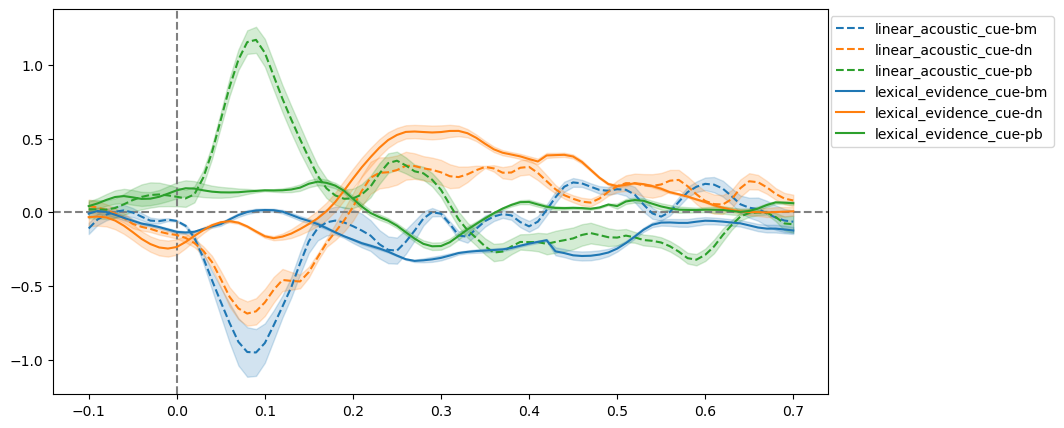

In [129]:
plot_features(r"linear_acoustic|lexical_evidence", "EC253", 21)

(3, 15, 81)


(['categorical_acoustic_cue-bm',
  'categorical_acoustic_cue-dn',
  'categorical_acoustic_cue-pb',
  'lexical_evidence_cue-bm',
  'lexical_evidence_cue-dn',
  'lexical_evidence_cue-pb'],
 array([[ 1.68183843e-02, -6.12444867e-03, -2.39183140e-02,
         -2.61616850e-02, -2.05539372e-02, -1.41681210e-02,
         -8.21585865e-03, -9.74729843e-03, -2.03453984e-02,
         -3.70380535e-02, -5.51158311e-02, -7.17477337e-02,
         -8.61707226e-02, -9.46384114e-02, -9.18673145e-02,
         -8.29576377e-02, -8.33817378e-02, -9.53145760e-02,
         -1.04916275e-01, -1.02449919e-01, -9.09470650e-02,
         -8.14537663e-02, -8.00215279e-02, -8.93036308e-02,
         -9.60863361e-02, -9.72136105e-02, -9.01959171e-02,
         -8.70120047e-02, -5.70548336e-02, -5.47987777e-02,
         -5.37167367e-02, -5.03997055e-02, -4.32414956e-02,
         -3.57139794e-02, -1.87806378e-02,  1.19336069e-03,
          1.50074326e-02,  2.11818195e-02,  1.61089631e-02,
          9.82729682e-03,  5.2181

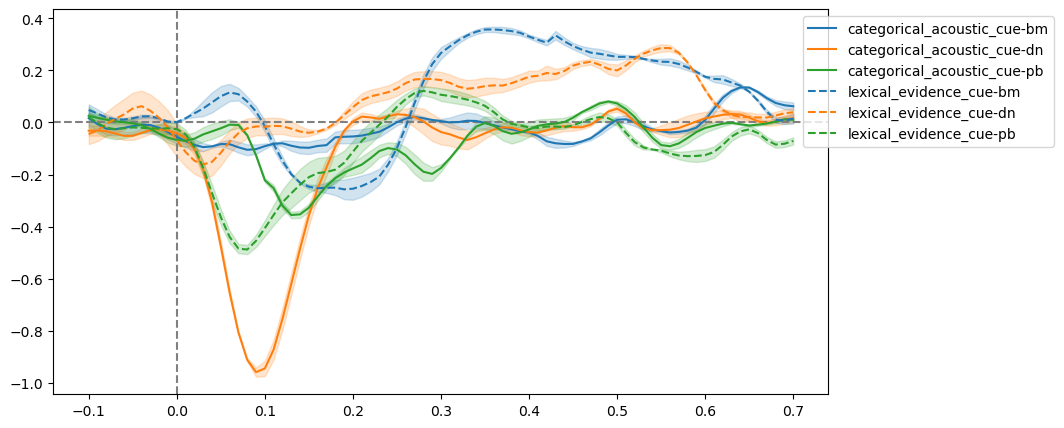

In [176]:
plot_features(r"acoustic|lexical_evidence", "EC248", 382)

(4, 18, 81)


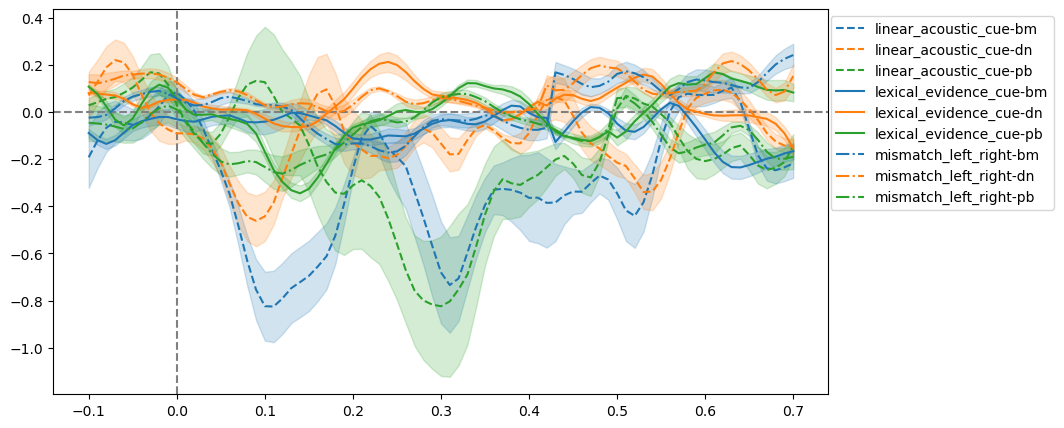

In [49]:
plot_features(r"linear_acoustic|lexical_evidence|mismatch_left_right", "EC282", 84)

(4, 18, 81)


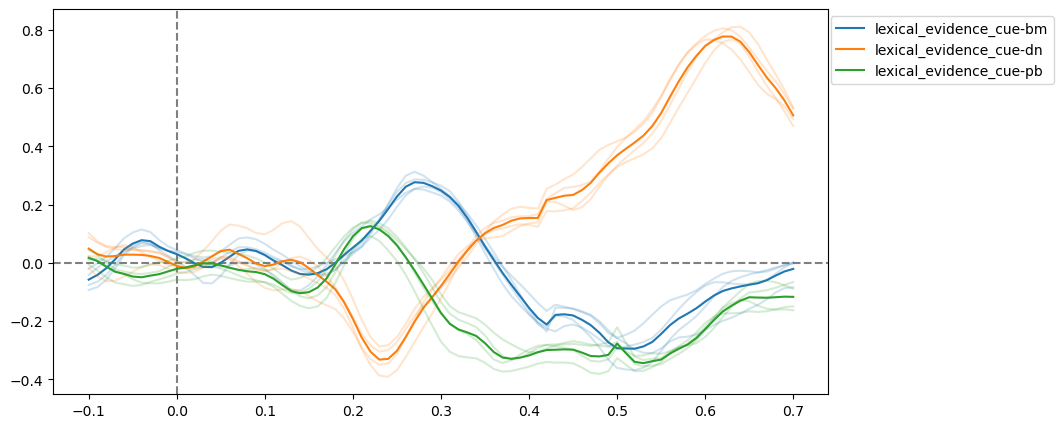

In [53]:
plot_features(r"lexical_evidence", "EC278", 85, True)

(4, 18, 81)


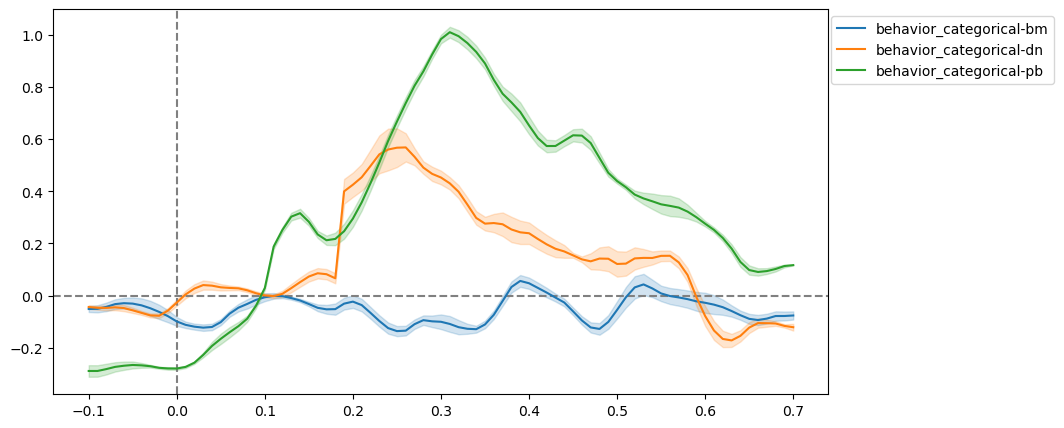

In [26]:
plot_features(r"behavior", "EC260", 206)

(4, 21, 81)


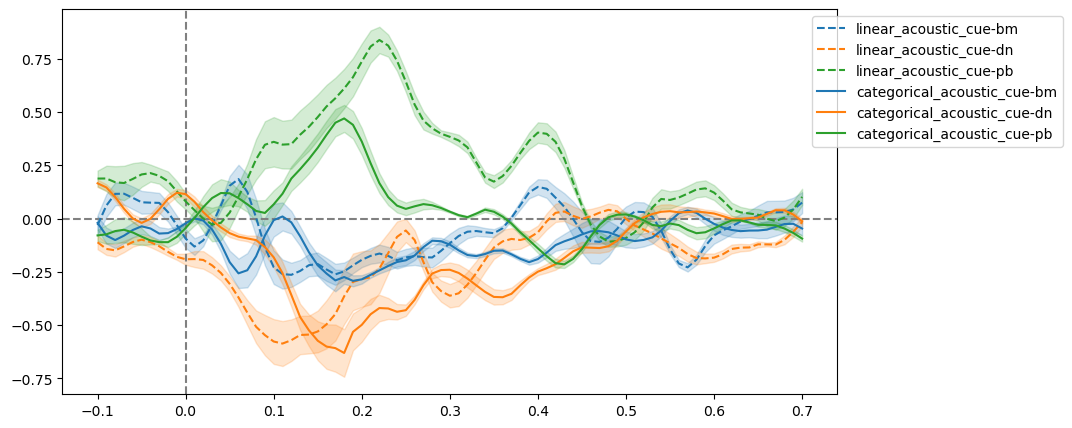

In [23]:
plot_features(r"linear_acoustic|categorical_acoustic", "EC250", 215)

In [22]:
next(iter(all_trfs.values()))["estimators"][0].estimator_

TimeDelayingRidge({'alpha': 56.23413251903491,
 'edge_correction': True,
 'fit_intercept': True,
 'n_jobs': None,
 'reg_type': 'ridge',
 'sfreq': 100.0,
 'tmax': 0.7,
 'tmin': -0.1})